In [2]:
# Importing the necessary libraries
import os  # For working with files and directories
import torch  # PyTorch
import torch.nn as nn  # Neural network module
import torchvision.transforms as transforms  # image transformation
from torchvision.models import resnet50, ResNet50_Weights  # Importing the ResNet50 model
from PIL import Image  # image processing library
import psycopg2  # PostgreSQL database adapter

In [3]:
def load_model():
    """
    Loads the pre-trained ResNet50 model and sets it to evaluation mode.

    Returns:
        model: The loaded ResNet50 model.
    """
    # Use the recommended weights argument instead of pretrained
    weights = ResNet50_Weights.IMAGENET1K_V1  # Alternatively, use ResNet50_Weights.DEFAULT for the latest weights
    model = resnet50(weights=weights)  # Load the model with specified weights
    
    # Remove the last fully connected layer to get 2048-dimensional outputs
    model = torch.nn.Sequential(*list(model.children())[:-1])  # Keep all layers except the last one
    model.eval()  # Set the model to evaluation mode
    return model

In [4]:
def preprocess_image(image_path):
    """
    Preprocess the image.

    parameters:
        image_path (str): Image File Path

    Returns:
        torch.Tensor: Preprocessed image tensor
    """
    # Defining Image Transformation Operations
    transform = transforms.Compose([
        transforms.Resize(256),  # Resizing images
        transforms.CenterCrop(224),  # Center Cropped Image
        transforms.ToTensor(),  # Converting images to tensors
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # standardization
    ])
    
    image = Image.open(image_path).convert("RGB")  # Read images and convert to RGB format
    image_tensor = transform(image).unsqueeze(0)  # Add Batch Dimension
    return image_tensor

In [5]:
def generate_image_vector(model, image_path):
    """
    Generate a 2048-dimensional vector of images.

    parameters:
        model: Pre-trained ResNet50 model
        image_path (str): Image File Path

    Returns:
        numpy.ndarray: 2048-dimensional image vector
    """
    image_tensor = preprocess_image(image_path)  # Preprocessed images
    with torch.no_grad():  # Disable gradient calculation
        vector = model(image_tensor).numpy()  # Generate vectors using models and convert to numpy arrays
        flattened_vector= vector.flatten()
    return flattened_vector # Flatten vectors for easy storage


In [6]:
def search_similar_images(connection, input_vector, top_k):
    """
    Search for the most similar images in the database based on the input vector.

    Args:
        connection: The database connection.
        input_vector: The 2048-dimensional vector of the input image.
        top_k (int): The number of most similar images to retrieve.

    Returns:
        list: A list of tuples containing the article_id, product_code, vector, and distance.
    """
    vector_str = ','.join(map(str, input_vector))  # Convert vector to string format for query
    vector_str = f'[{vector_str}]'
    
    query = """
    SELECT i.vector::text, i.vector <=> %s AS distance
    FROM image_info i
    ORDER BY distance
    LIMIT %s;
    """
    
    with connection.cursor() as cursor:
        cursor.execute(query, (vector_str, top_k))
        results = cursor.fetchall()
    
    return results


In [7]:
def search_similar_images(connection, input_vector, top_k):
    """
    Search for similar images in the database using pgvector.

    Args:
        connection: PostgreSQL database connection.
        input_vector (list): The 2048-dimensional input vector.
        top_k (int): The number of most similar images to retrieve.

    Returns:
        list: A list of tuples containing article_id, product_code, vector, and distances.
    """
    vector_str = ','.join(map(str, input_vector))
    vector_str = f'[{vector_str}]'

    print("users image vector_str: ",vector_str)
    
    # Modified query to also return the vector from the database
    query = """
    SELECT i.vector, i.vector <=> %s AS distance
    FROM image_info i
    JOIN product_info p ON i.article_id = p.article_id
    ORDER BY distance
    LIMIT %s;
    """
    
    with connection.cursor() as cursor:
        cursor.execute(query, (vector_str, top_k))  # Execute the query
        results = cursor.fetchall()  # Get the top_k results
    
    print("similar image vector from database: ",results)
    
    return results  # Return the retrieved vectors and distances


In [8]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_vectors(user_vector, similar_results):
    """
    Visualize the user vector and top_k similar vectors using t-SNE.

    Args:
        user_vector (list): The 2048-dimensional vector of the input image.
        similar_results (list): List of tuples containing article_id, product_code, vector, and distance.

    Returns:
        None
    """
    
    print("user_image_vector: ",user_vector)
    
    print("similar_results_fromDB: ",similar_results)

    # Extract vectors from the results
    extract_similar_vectors = np.array([result[0] for result in similar_results])
    
    print("extract_similar_vectors: ",extract_similar_vectors)

    # Combine the user's vector with the similar vectors
    all_vectors = np.vstack([user_vector, extract_similar_vectors])
    
    print("all_vectors: ",all_vectors)

    # Use t-SNE to reduce dimensionality to 2D
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_vectors = tsne.fit_transform(all_vectors)

    # Plot the t-SNE results
    plt.figure(figsize=(8, 6))
    
    # Plot the user's vector in red
    plt.scatter(reduced_vectors[0, 0], reduced_vectors[0, 1], color='red', label='User Vector', marker='x', s=200)

    # Plot the similar vectors in blue
    plt.scatter(reduced_vectors[1:, 0], reduced_vectors[1:, 1], color='blue', label='Similar Vectors')

    # Annotate the similar vectors with their product codes
    for i, result in enumerate(similar_results):
        plt.annotate(result[1], (reduced_vectors[i+1, 0], reduced_vectors[i+1, 1]))

    plt.legend()
    plt.title("t-SNE Visualization of User Vector and Similar Vectors")
    plt.show()

In [9]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import ast  # 用于将字符串转换为列表

def visualize_vectors(user_vector, similar_results, max_perplexity=50):
    """
    Visualize the user vector and top_k similar vectors using t-SNE.

    Args:
        user_vector (list): The 2048-dimensional vector of the input image.
        similar_results (list): List of tuples containing article_id, product_code, vector, and distance.
        max_perplexity (int): The maximum value for perplexity, default is 50.

    Returns:
        None
    """
    
    print("user_image_vector: ", user_vector)
    print("similar_results_fromDB: ", similar_results)

    # Extract and convert vectors from the results (converting from string format)
    extract_similar_vectors = np.array([np.array(ast.literal_eval(result[0])) for result in similar_results])
    
    print("extract_similar_vectors: ", extract_similar_vectors)

    # Combine the user's vector with the similar vectors
    all_vectors = np.vstack([user_vector, extract_similar_vectors])
    
    print("all_vectors: ", all_vectors)

    # Dynamically adjust perplexity based on the number of vectors
    perplexity_value = min(max_perplexity, len(all_vectors) // 2)
    
    # Use t-SNE to reduce dimensionality to 2D
    tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)
    reduced_vectors = tsne.fit_transform(all_vectors)

    # Plot the t-SNE results
    plt.figure(figsize=(8, 6))
    
    # Plot the user's vector in red
    plt.scatter(reduced_vectors[0, 0], reduced_vectors[0, 1], color='red', label='User Vector', marker='x', s=200)

    # Plot the similar vectors in blue
    plt.scatter(reduced_vectors[1:, 0], reduced_vectors[1:, 1], color='blue', label='Similar Vectors')

    # Annotate the similar vectors with their product codes
    for i, result in enumerate(similar_results):
        plt.annotate(result[1], (reduced_vectors[i+1, 0], reduced_vectors[i+1, 1]))

    plt.legend()
    plt.title("t-SNE Visualization of User Vector and Similar Vectors")
    plt.show()

users image vector_str:  [0.71380824,1.0484533,0.0070424373,0.24500579,0.6634018,0.36668587,0.09644938,0.10159736,0.9433896,1.6448456,0.564921,0.005212267,0.30708912,0.0367037,1.1522002,0.031897157,0.54167587,0.07573987,0.18089968,0.04942892,0.50286406,0.34370944,0.009988085,0.18566178,10.110823,0.073345505,0.59395033,0.47851935,0.19485036,0.0331802,0.9232467,0.2998796,0.013818088,0.24669273,0.23398429,0.116830625,0.015140133,0.03564619,0.14588042,0.09116603,0.24566929,0.09811144,0.56726474,0.18287823,1.1665146,0.694531,0.05624268,1.1124991,0.10349337,0.0036787859,0.14618441,0.6094243,0.0140216425,0.3183445,0.33981645,0.31539702,0.0,0.20261447,0.0057878215,0.1516213,0.13293836,0.11674005,0.33212027,0.025745386,0.08341179,0.021234425,0.07816525,0.9324059,0.0,0.10089848,0.02474778,0.07542625,0.27564394,0.23671615,0.56479716,0.9540285,0.116271615,0.042609647,0.003732693,0.31572738,0.1849528,0.7170916,0.19865742,0.07510525,0.7816467,0.28719917,0.010870267,0.5741529,0.60289335,0.17550945,0.

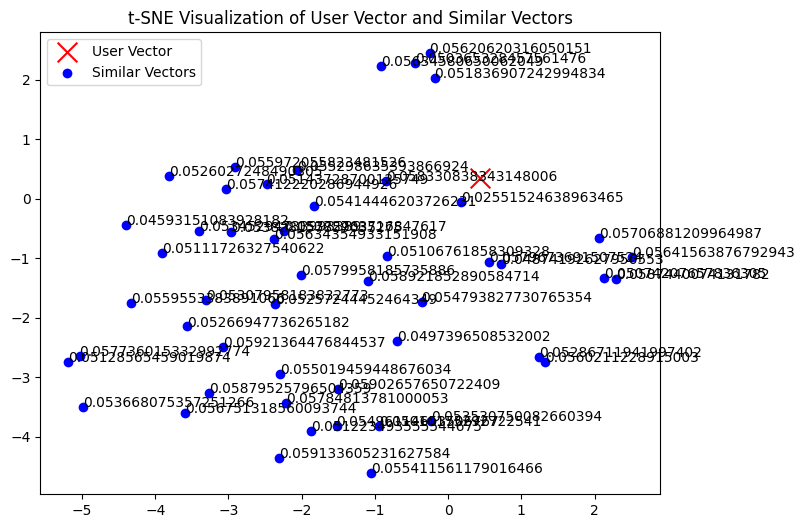

In [11]:
import psycopg2  # PostgreSQL database adapter

# Main search and visualize function

TOP_K = 50  # Number of similar images to retrieve

# image_path = "/Users/Tommy/AI/image-search/clothing-images/050/0501619010.jpg"
image_path = "/Users/Tommy/Downloads/man-pants.png"
# image_path = "/Users/Tommy/Snipaste/Snipaste_2024-10-24_12-54-18.png"
# image_path = "/Users/Tommy/AI/image-search/clothing-images/050/0501619010.jpg"

# Connecting to PostgreSQL Database
connection = psycopg2.connect(
        dbname='image-search',  
        user='postgres',  
        password='test-postgres',  
        host='localhost',  
        port='5432'  
    )

model = load_model()  # Load the ResNet50 model

# Step 1: Extract user vector from the image
flattened_user_vector = generate_image_vector(model, image_path) 
# flattened_vector:  [0.3435464  0.73842794 0.91404784 ... 0.02022145 0.50024617 0.42373607]

# Step 2: Find similar images
similar_images_vector = search_similar_images(connection, flattened_user_vector, TOP_K)

# Step 3: Visualize the user vector and similar images
visualize_vectors(flattened_user_vector, similar_images_vector)

connection.close()  # Close the database connection
